# 06 — Modelo CNN - ResNet34

## Activar GPU NVIDIA

In [1]:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Usando dispositivo: {device}")


2.5.1
True
NVIDIA GeForce RTX 4070 Laptop GPU
Usando dispositivo: cuda


## 1 · Imports y configuración global

In [2]:
# ============================================================
# 1. IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================

# --- Librerías estándar ---
import pathlib, time, copy

# --- Data Science ---
import pandas  as pd
import numpy   as np
import matplotlib.pyplot as plt

# --- PyTorch core ---
import torch
import torch.nn            as nn
import torch.optim         as optim
from torch.utils.data import Dataset, DataLoader

# --- Torchvision ---
import torchvision.transforms as transforms
import torchvision.models     as models

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error

# --- PIL ---
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True   # evitar crashes con imágenes corruptas
Image.MAX_IMAGE_PIXELS = None            # suprimir DecompressionBombWarning

# --- tqdm ---
from tqdm import tqdm

# ============================================================
# CONSTANTES GLOBALES
# ============================================================

# Rutas  (mismas que notebooks anteriores)
SYNC_CSV  = pathlib.Path("../data/listingV5_PriceCapID.csv")
IMG_DIR   = pathlib.Path("../data/Front_Images_224/")
MODEL_DIR = pathlib.Path("../models/")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 500
LR          = 1e-3
RANDOM_SEED = 42

# Estadísticas de normalización ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibilidad
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Diagnóstico
W = 57
print("═" * W)
print(" SmartHost Analytics — CNN ResNet34".center(W))
print("═" * W)
print(f"  PyTorch     : {torch.__version__}")
print(f"  Dispositivo : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  ⚠️  Sin GPU — el entrenamiento será más lento en CPU.")
print(f"  IMG_SIZE    : {IMG_SIZE}×{IMG_SIZE} px")
print(f"  BATCH       : {BATCH_SIZE}")
print(f"  EPOCHS      : {NUM_EPOCHS}")
print(f"  LR base     : {LR}")
print("═" * W)


═════════════════════════════════════════════════════════
            SmartHost Analytics — CNN ResNet34           
═════════════════════════════════════════════════════════
  PyTorch     : 2.5.1
  Dispositivo : cuda
  GPU         : NVIDIA GeForce RTX 4070 Laptop GPU
  VRAM        : 8.6 GB
  IMG_SIZE    : 224×224 px
  BATCH       : 32
  EPOCHS      : 500
  LR base     : 0.001
═════════════════════════════════════════════════════════


## 1.1 · Sincronización Dataset (CSV ↔ Imágenes)

In [3]:
# ============================================================
# 1.1  SINCRONIZACIÓN CSV <-> IMÁGENES
# ============================================================
# Misma lógica que notebooks anteriores:
#   • Cargamos el CSV maestro listingV5_PriceCapID.csv
#   • Construimos el path esperado de cada imagen: <id>.jpg
#   • Descartamos filas sin imagen en disco
#   • Usamos random_state=42 para reproducir el mismo split

df_raw = pd.read_csv(SYNC_CSV)
print(f"CSV cargado  → {len(df_raw):,} filas, {df_raw.shape[1]} columnas")

# Construir paths y verificar existencia
df_raw["img_path"] = df_raw["id"].apply(lambda i: IMG_DIR / f"{i}.jpg")
mask_exists = df_raw["img_path"].apply(lambda p: p.exists())

n_disk   = mask_exists.sum()
n_drop   = (~mask_exists).sum()
df_sync  = df_raw[mask_exists].reset_index(drop=True)

# En el Dataset, normalizar precio
PRICE_MEAN = df_sync["price"].mean()   # ~111€
PRICE_STD  = df_sync["price"].std()    # ~61€

print(f"Imágenes en disco  → {n_disk:,}")
print()
print(f"  Filas en CSV original    : {len(df_raw):,}")
print(f"  Imágenes disponibles     : {n_disk:,}")
print(f"  Filas ELIMINADAS s/img   : {n_drop:,} ({n_drop/len(df_raw)*100:.1f} %)")
print(f"  Filas SINCRONIZADAS      : {len(df_sync):,}")
print()
print("📊 Estadísticas de precio:")
print(df_sync["price"].describe().round(2).to_string())


CSV cargado  → 5,667 filas, 32 columnas
Imágenes en disco  → 5,667

  Filas en CSV original    : 5,667
  Imágenes disponibles     : 5,667
  Filas ELIMINADAS s/img   : 0 (0.0 %)
  Filas SINCRONIZADAS      : 5,667

📊 Estadísticas de precio:
count    5667.00
mean      111.77
std        61.67
min        18.00
25%        75.00
50%        98.00
75%       132.00
max       450.00


## 2 · Dataset personalizado

In [4]:
# ============================================================
# 2. DATASET PERSONALIZADO
# ============================================================

class AirbnbImageDataset(Dataset):
    """
    Devuelve (imagen_tensor, precio_float) para cada apartamento.
    Tolera imágenes corruptas: si falla la carga devuelve un
    tensor negro y el precio real (no aborta el entrenamiento).
    """
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = pathlib.Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        # __getitem__: devolver precio normalizado
        price = (float(row["price"]) - PRICE_MEAN) / PRICE_STD
        path  = self.img_dir / f"{row['id']}.jpg"
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, price

print("✅ Clase AirbnbImageDataset definida.")


✅ Clase AirbnbImageDataset definida.


## 2.2 · Pipelines de transformación

> Las imágenes ya están pre-procesadas a 224×224.


In [5]:
# ============================================================
# 2.2  PIPELINES DE TRANSFORMACIÓN
#      Train: augmentation enriquecido
#      Val  : sólo tensor + normalización (determinista)
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    # Augmentation más agresivo en transforms_train
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Pipelines de transformación definidos.")
print("\ntransform_train:")
for i, t in enumerate(transform_train.transforms):
    marker = "  ← solo train" if type(t).__name__ not in ("ToTensor","Normalize") else ""
    print(f"  {i+1}. {type(t).__name__}{marker}")
print("\ntransform_val:")
for i, t in enumerate(transform_val.transforms):
    print(f"  {i+1}. {type(t).__name__}")


✅ Pipelines de transformación definidos.

transform_train:
  1. RandomHorizontalFlip  ← solo train
  2. ColorJitter  ← solo train
  3. RandomRotation  ← solo train
  4. RandomAffine  ← solo train
  5. ToTensor
  6. Normalize

transform_val:
  1. ToTensor
  2. Normalize


## 2.3 · Split Train/Val y DataLoaders

In [6]:
# ============================================================
# 2.3  SPLIT TRAIN/VAL  (random_state=42 — mismo que notebooks anteriores)
# ============================================================

df_train, df_val = train_test_split(
    df_sync,
    test_size=0.2,
    random_state=RANDOM_SEED
)

dataset_train = AirbnbImageDataset(df_train, IMG_DIR, transform=transform_train)
dataset_val   = AirbnbImageDataset(df_val,   IMG_DIR, transform=transform_val)

loader_train = DataLoader(
    dataset_train, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=0, pin_memory=True
)
loader_val = DataLoader(
    dataset_val,   batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)

print("=" * 50)
print("  RESUMEN DE SPLITS Y DATALOADERS")
print("=" * 50)
print(f"  Total apartamentos sync : {len(df_sync):,}")
print(f"  Train                   : {len(dataset_train):,} imágenes ({len(loader_train)} batches)")
print(f"  Val                     : {len(dataset_val):,}   imágenes ({len(loader_val)} batches)")
print(f"  Batch size              : {BATCH_SIZE}")
print(f"  pin_memory              : True (GPU activa)")
print("=" * 50)


  RESUMEN DE SPLITS Y DATALOADERS
  Total apartamentos sync : 5,667
  Train                   : 4,533 imágenes (142 batches)
  Val                     : 1,134   imágenes (36 batches)
  Batch size              : 32
  pin_memory              : True (GPU activa)


## 2.4 · Sanity check visual

📐 Shape del batch  : torch.Size([32, 3, 224, 224])  → [batch, canales, alto, ancho]
💰 Precios del batch (primeros 8): [0 0 0 0 0 0 0 1] €/noche
   min=-1€ | max=4€ | media=0€


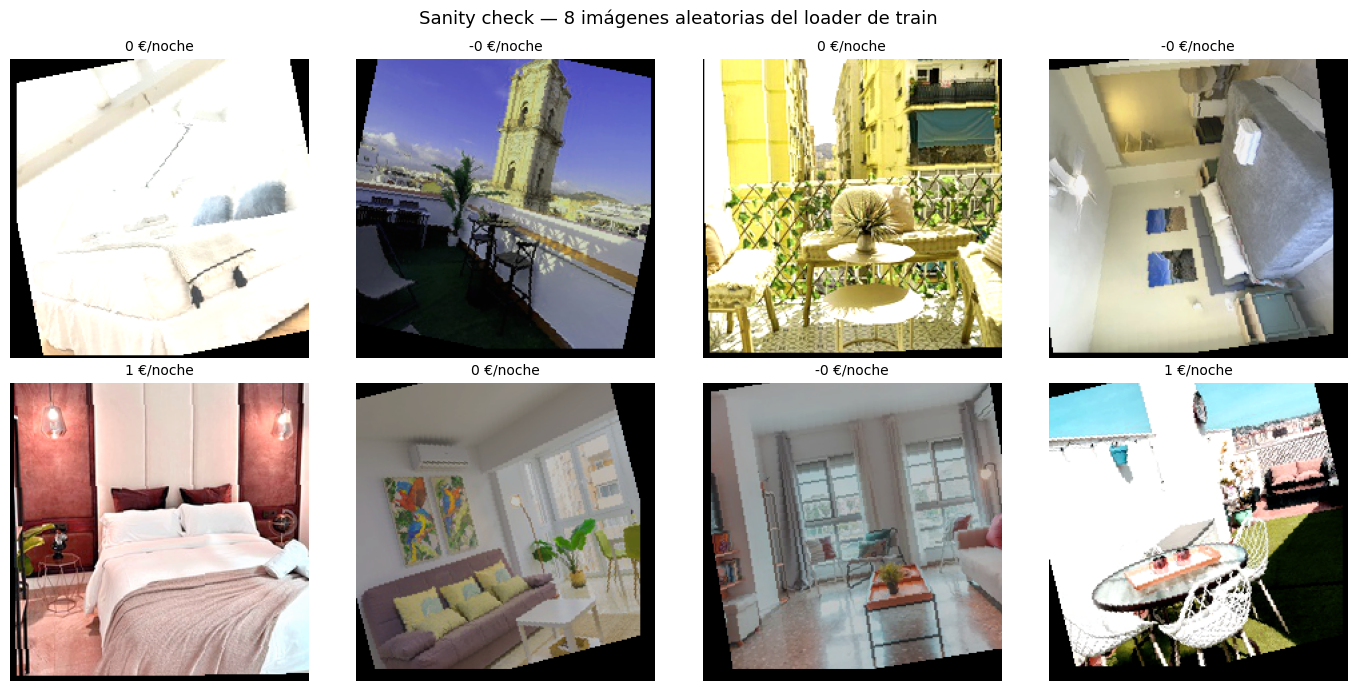

✅ Sanity check OK.


In [7]:
# ============================================================
# 2.4  SANITY CHECK VISUAL
# ============================================================

imgs, prices = next(iter(loader_train))
print(f"📐 Shape del batch  : {imgs.shape}  → [batch, canales, alto, ancho]")
print(f"💰 Precios del batch (primeros 8): {prices[:8].numpy().astype(int)} €/noche")
print(f"   min={prices.min():.0f}€ | max={prices.max():.0f}€ | media={prices.mean():.0f}€")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std  = torch.tensor(IMAGENET_STD).view(3,1,1)

for ax, img, price in zip(axes.flat, imgs[:8], prices[:8]):
    img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(f"{price:.0f} €/noche", fontsize=10)
    ax.axis("off")

plt.suptitle("Sanity check — 8 imágenes aleatorias del loader de train", fontsize=13)
plt.tight_layout()
plt.show()
print("✅ Sanity check OK.")


## 3 · Arquitectura ResNet34

ResNet34 es una red residual de 34 capas con **skip connections** que evitan el problema del gradiente desvaneciente.
Comparada con las otras arquitecturas del proyecto:

| Modelo | Parámetros | Top-1 ImageNet | Profundidad | Tipo backbone |
|--------|-----------|----------------|-------------|---------------|
| MobileNetV2 | ~3.4 M | 71.8 % | 53 capas | Separable conv |
| EfficientNet-B0 | ~5.3 M | 77.1 % | 237 capas | MBConv + SE |
| **ResNet34** | **~21.8 M** | **73.3 %** | **34 capas** | **Residual blocks** |

**Modificación para regresión de precios:**
- Se reemplaza la cabeza `fc` (1000 clases → 1 neurona de salida)
- Durante el **warm-up** (primeras 10 epochs) todo el backbone está congelado
- En el **fine-tuning** se descongela `layer3` + `layer4` + `fc`


In [8]:
# ============================================================
# 3. ARQUITECTURA  ResNet34 → Regresor de precio
# ============================================================

class ResNet34Regressor(nn.Module):
    """
    ResNet34 preentrenada en ImageNet con la cabeza fc
    sustituida por un regresor de precio (salida escalar).

    Cabeza:
        Linear(512 → 256) → ReLU → Dropout(0.4)
        Linear(256 → 1)
    """
    def __init__(self, dropout: float = 0.4):
        super().__init__()
        backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        in_features = backbone.fc.in_features        # 512

        # Congelar todo el backbone inicialmente (warm-up)
        for param in backbone.parameters():
            param.requires_grad = False

        # Guardar capas por nombre para poder descongelarlas luego
        self.conv1   = backbone.conv1
        self.bn1     = backbone.bn1
        self.relu    = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        self.avgpool = backbone.avgpool

        # Nueva cabeza de regresión (siempre entrenable)
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),        # 0.4 → 0.5
            nn.Linear(256, 128),    # añadir capa intermedia
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.conv1(x);   x = self.bn1(x)
        x = self.relu(x);    x = self.maxpool(x)
        x = self.layer1(x);  x = self.layer2(x)
        x = self.layer3(x);  x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x).squeeze(1)


model = ResNet34Regressor(dropout=0.4).to(DEVICE)

# ── Tabla de parámetros ───────────────────────────────────────────────────────
total   = sum(p.numel() for p in model.parameters())
train_  = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen  = total - train_

print("=" * 52)
print("  ResNet34  — tabla de parámetros")
print("=" * 52)
print(f"  Total      : {total:>10,}")
print(f"  Entrenables: {train_:>10,}  (cabeza fc)")
print(f"  Congelados : {frozen:>10,}  (backbone)")
print("=" * 52)
print()

# ── Comparativa arquitecturas del proyecto ────────────────────────────────────
rows = [
    ("MobileNetV2",    "~3.4 M",  "71.8 %", "Warm-up 10ep  | Unfreeze features[5:]"),
    ("EfficientNet-B0","~5.3 M",  "77.1 %", "Warm-up 10ep  | Unfreeze features[5:]"),
    ("ResNet34",       "~21.8 M", "73.3 %", "Warm-up 10ep  | Unfreeze layer3+layer4"),
]
print(f"  {'Modelo':<18} {'Params':<10} {'Top-1':>7}  {'Estrategia fine-tuning'}")
print("  " + "-"*70)
for r in rows:
    mark = " ◀ este" if r[0]=="ResNet34" else ""
    print(f"  {r[0]:<18} {r[1]:<10} {r[2]:>7}  {r[3]}{mark}")


  ResNet34  — tabla de parámetros
  Total      : 21,449,025
  Entrenables:    164,353  (cabeza fc)
  Congelados : 21,284,672  (backbone)

  Modelo             Params       Top-1  Estrategia fine-tuning
  ----------------------------------------------------------------------
  MobileNetV2        ~3.4 M      71.8 %  Warm-up 10ep  | Unfreeze features[5:]
  EfficientNet-B0    ~5.3 M      77.1 %  Warm-up 10ep  | Unfreeze features[5:]
  ResNet34           ~21.8 M     73.3 %  Warm-up 10ep  | Unfreeze layer3+layer4 ◀ este


## 4 · Loss, optimizer y scheduler

In [9]:
# ============================================================
# 4. LOSS / OPTIMIZER / SCHEDULER
# ============================================================

criterion = nn.L1Loss()    # MAE — robusto frente a outliers de precio

# En warm-up sólo entrenamos la cabeza fc
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=LR,
    # weight_decay más alto en fine-tuning
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

print("✅ Loss     : L1Loss (MAE)")
print(f"✅ Optimizer: Adam  lr={LR}, weight_decay=1e-4  (solo cabeza fc)")
print("✅ Scheduler: ReduceLROnPlateau  factor=0.5, patience=5, min_lr=1e-6")


✅ Loss     : L1Loss (MAE)
✅ Optimizer: Adam  lr=0.001, weight_decay=1e-4  (solo cabeza fc)
✅ Scheduler: ReduceLROnPlateau  factor=0.5, patience=5, min_lr=1e-6


## 5 · Funciones auxiliares (train_epoch / eval_epoch)

In [10]:
# ============================================================
# 5. HELPERS — train_epoch / eval_epoch
# ============================================================

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    sum_mse = sum_mae = n = 0.0          # ← sum_mse inicializado aquí ✅

    for imgs, prices in tqdm(loader, desc="  [TRAIN]", leave=False):
        imgs   = imgs.to(device)
        prices = prices.to(device)       # valores normalizados

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, prices) # loss en escala normalizada
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ── Desnormalizar para métricas en € ────────────────────────────────
        preds_real  = preds.detach()  * PRICE_STD + PRICE_MEAN
        prices_real = prices          * PRICE_STD + PRICE_MEAN

        bs       = prices.size(0)
        sum_mae += (preds_real - prices_real).abs().sum().item()
        sum_mse += ((preds_real - prices_real) ** 2).sum().item()  # ← ahora sí existe
        n       += bs

    return sum_mse / n, sum_mae / n     # MSE en €²,  MAE en €


def eval_epoch(model, loader, criterion, device):
    model.eval()
    all_preds, all_true = [], []
    sum_mse = sum_mae = n = 0.0          # ← también inicializado

    with torch.no_grad():
        for imgs, prices in tqdm(loader, desc="  [VAL]  ", leave=False):
            imgs   = imgs.to(device)
            prices = prices.to(device)

            preds = model(imgs)

            # ── Desnormalizar ────────────────────────────────────────────────
            preds_real  = preds  * PRICE_STD + PRICE_MEAN
            prices_real = prices * PRICE_STD + PRICE_MEAN

            bs       = prices.size(0)
            sum_mae += (preds_real - prices_real).abs().sum().item()
            sum_mse += ((preds_real - prices_real) ** 2).sum().item()
            n       += bs
            all_preds.extend(preds_real.cpu().numpy())
            all_true.extend(prices_real.cpu().numpy())

    mse  = sum_mse / n
    mae  = sum_mae / n
    rmse = np.sqrt(mse)
    r2   = r2_score(all_true, all_preds)
    return mse, mae, rmse, r2


print("✅ train_epoch y eval_epoch definidas.")


✅ train_epoch y eval_epoch definidas.


## 6 · Early Stopping

In [11]:
# ============================================================
# 6. EARLY STOPPING
# ============================================================

class EarlyStopping:
    """
    Detiene el entrenamiento si Val MAE no mejora en `patience` epochs.
    Guarda automáticamente los mejores pesos en model_path.
    """
    def __init__(self, patience=15, delta=0.0, model_path=None):
        self.patience     = patience
        self.delta        = delta
        self.model_path   = model_path or MODEL_DIR / "resnet34_best.pt"
        self.best_mae     = float("inf")
        self.counter      = 0
        self.best_weights = None

    def step(self, val_mae, model):
        if val_mae < self.best_mae - self.delta:
            self.best_mae     = val_mae
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            torch.save(self.best_weights, self.model_path)
            return "best"
        else:
            self.counter += 1
            return f"wait {self.counter}/{self.patience}"

    @property
    def stop(self):
        return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_weights)


early_stop = EarlyStopping(patience=15, model_path=MODEL_DIR / "resnet34_best.pt")
print(f"✅ EarlyStopping (patience=15) → guarda en '{early_stop.model_path}'")


✅ EarlyStopping (patience=15) → guarda en '..\models\resnet34_best.pt'


## 7 · Bucle de entrenamiento principal

### Estrategia de dos fases

| Fase | Epochs | Backbone | LR cabeza | Objetivo |
|------|--------|----------|-----------|----------|
| **Warm-up** | 1–10 | Congelado completo | 1e-3 | Ajustar la nueva cabeza fc |
| **Fine-tuning** | 11+ | layer3 + layer4 desbloqueados | 5e-5 | Especializar en interiores |


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# 7. BUCLE DE ENTRENAMIENTO  —  Warm-up → Fine-tuning
# ════════════════════════════════════════════════════════════════════════════

WARMUP_EPOCHS  = 10      # epochs con backbone congelado
LR_FINETUNE    = 5e-5    # LR para capas descongeladas

history = {k: [] for k in ("tr_mse","tr_mae","va_mse","va_mae","va_rmse","r2","lr")}

print(f"{'Ep':>4} | {'Tr.MSE':>8} | {'Tr.MAE':>8} | "
      f"{'Va.MSE':>8} | {'Va.MAE':>8} | {'Va.RMSE':>8} | "
      f"{'R²':>6} | {'LR':>8} | Estado")
print("-" * 105)

t_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Descongelado parcial al terminar warm-up ──────────────────────────────
    if epoch == WARMUP_EPOCHS + 1:
        print(f"\n🔓  Epoch {epoch}: Descongelando layer3 + layer4 con LR_finetune={LR_FINETUNE}\n")
        for layer in [model.layer3, model.layer4]:
            for param in layer.parameters():
                param.requires_grad = True

        optimizer = optim.Adam([
            {"params": model.layer3.parameters(), "lr": LR_FINETUNE},
            {"params": model.layer4.parameters(), "lr": LR_FINETUNE},
            {"params": model.fc.parameters(),     "lr": LR_FINETUNE},
        ], weight_decay=1e-4)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
        )

    # ── Train ─────────────────────────────────────────────────────────────────
    tr_mse, tr_mae = train_epoch(model, loader_train, criterion, optimizer, DEVICE)

    # ── Val ───────────────────────────────────────────────────────────────────
    va_mse, va_mae, va_rmse, r2 = eval_epoch(model, loader_val, criterion, DEVICE)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    scheduler.step(va_mae)
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Early Stopping ────────────────────────────────────────────────────────
    status = early_stop.step(va_mae, model)
    icon   = "✅ Mejor" if status == "best" else f"⏳ {status}"

    # ── Historial ─────────────────────────────────────────────────────────────
    for k, v in zip(history, [tr_mse, tr_mae, va_mse, va_mae, va_rmse, r2, current_lr]):
        history[k].append(v)

    # ── Print fila ────────────────────────────────────────────────────────────
    print(
        f"{epoch:>4} | {tr_mse:>8.1f} | {tr_mae:>7.2f}€ | "
        f"{va_mse:>8.1f} | {va_mae:>7.2f}€ | {va_rmse:>7.2f}€ | "
        f"{r2:>6.3f} | {current_lr:>8.2e} | {icon}"
    )

    if early_stop.stop:
        print(f"\n🛑  Early Stopping en epoch {epoch} — mejor Val MAE: {early_stop.best_mae:.2f}€")
        break

# ── Restaurar mejores pesos ───────────────────────────────────────────────────
early_stop.restore(model)
best_ep  = history["va_mae"].index(min(history["va_mae"])) + 1
best_r2  = history["r2"][best_ep - 1]
best_tr  = history["tr_mae"][best_ep - 1]
elapsed  = time.time() - t_start

print(f"\n✅  Pesos del mejor modelo restaurados (epoch {best_ep})")
print(f"   Val MAE = {early_stop.best_mae:.2f}€  |  Train MAE = {best_tr:.2f}€  |  Val R² = {best_r2:.3f}")
print(f"   Tiempo total de entrenamiento: {elapsed/60:.1f} min")


  Ep |   Tr.MSE |   Tr.MAE |   Va.MSE |   Va.MAE |  Va.RMSE |     R² |       LR | Estado
---------------------------------------------------------------------------------------------------------


   1 |   3982.8 |   41.98€ |   4127.1 |   41.45€ |   64.24€ | -0.045 | 1.00e-03 | ✅ Mejor


   2 |   3761.7 |   39.91€ |   3804.8 |   39.93€ |   61.68€ |  0.037 | 1.00e-03 | ✅ Mejor


   3 |   3642.0 |   39.35€ |   3888.5 |   40.51€ |   62.36€ |  0.016 | 1.00e-03 | ⏳ wait 1/15


   4 |   3655.6 |   39.40€ |   3880.6 |   40.14€ |   62.29€ |  0.018 | 1.00e-03 | ⏳ wait 2/15


...

  35 |   1056.7 |   18.96€ |   3231.0 |   38.34€ |   56.84€ |  0.182 | 1.25e-05 | ⏳ wait 11/15


  36 |   1019.2 |   18.40€ |   3336.0 |   38.54€ |   57.76€ |  0.156 | 6.25e-06 | ⏳ wait 12/15


  37 |   1029.8 |   18.32€ |   3283.0 |   38.32€ |   57.30€ |  0.169 | 6.25e-06 | ⏳ wait 13/15


  38 |    950.0 |   17.76€ |   3282.9 |   38.16€ |   57.30€ |  0.169 | 6.25e-06 | ⏳ wait 14/15


  39 |    942.2 |   17.73€ |   3303.5 |   38.56€ |   57.48€ |  0.164 | 6.25e-06 | ⏳ wait 15/15

🛑  Early Stopping en epoch 39 — mejor Val MAE: 36.82€

✅  Pesos del mejor modelo restaurados (epoch 24)
   Val MAE = 36.82€  |  Train MAE = 24.71€  |  Val R² = 0.174
   Tiempo total de entrenamiento: 64.9 min


## 8 · Curvas de aprendizaje

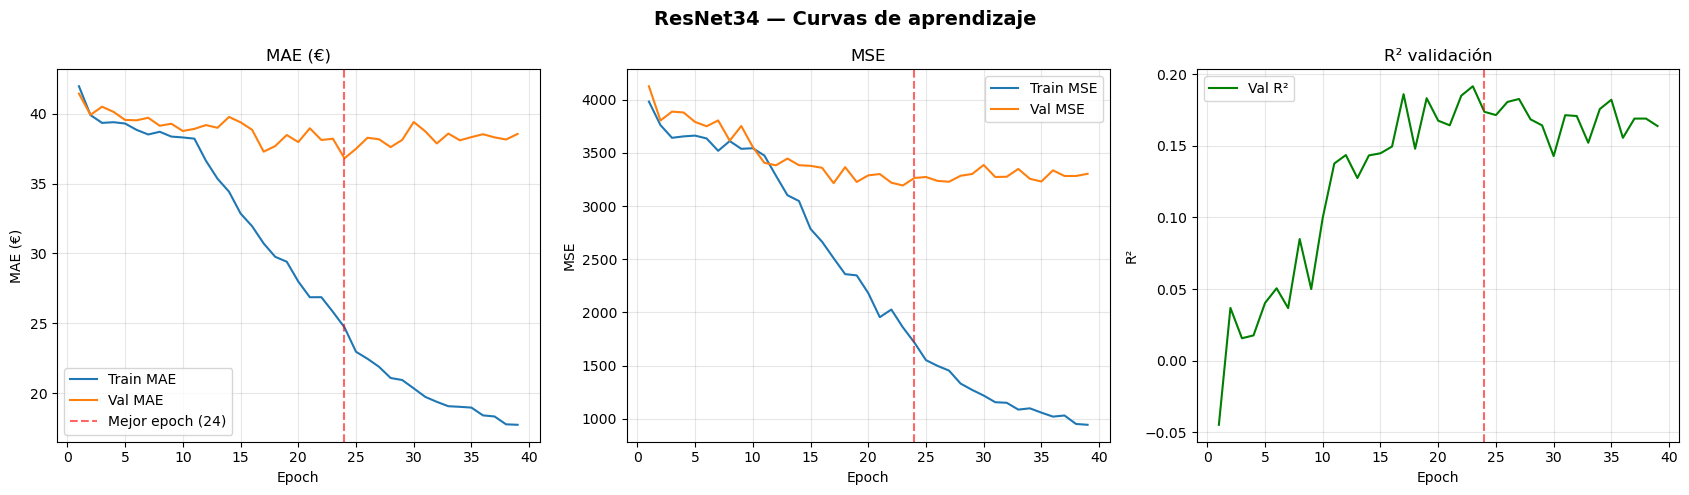

✅ Curvas guardadas en models/resnet34_learning_curves.png


In [13]:
# ============================================================
# 8. CURVAS DE APRENDIZAJE
# ============================================================

epochs_range = range(1, len(history["tr_mae"]) + 1)
best_ep      = history["va_mae"].index(min(history["va_mae"])) + 1

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("ResNet34 — Curvas de aprendizaje", fontsize=14, fontweight="bold")

# --- MAE ---
ax = axes[0]
ax.plot(epochs_range, history["tr_mae"], label="Train MAE", linewidth=1.5)
ax.plot(epochs_range, history["va_mae"], label="Val MAE",   linewidth=1.5)
ax.axvline(best_ep, color="red", linestyle="--", alpha=0.6, label=f"Mejor epoch ({best_ep})")
ax.set_title("MAE (€)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (€)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- MSE ---
ax = axes[1]
ax.plot(epochs_range, history["tr_mse"], label="Train MSE", linewidth=1.5)
ax.plot(epochs_range, history["va_mse"], label="Val MSE",   linewidth=1.5)
ax.axvline(best_ep, color="red", linestyle="--", alpha=0.6)
ax.set_title("MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(True, alpha=0.3)

# --- R² ---
ax = axes[2]
ax.plot(epochs_range, history["r2"], label="Val R²", color="green", linewidth=1.5)
ax.axvline(best_ep, color="red", linestyle="--", alpha=0.6)
ax.set_title("R² validación")
ax.set_xlabel("Epoch")
ax.set_ylabel("R²")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "resnet34_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Curvas guardadas en models/resnet34_learning_curves.png")


## 9 · Scatter predicho vs. real

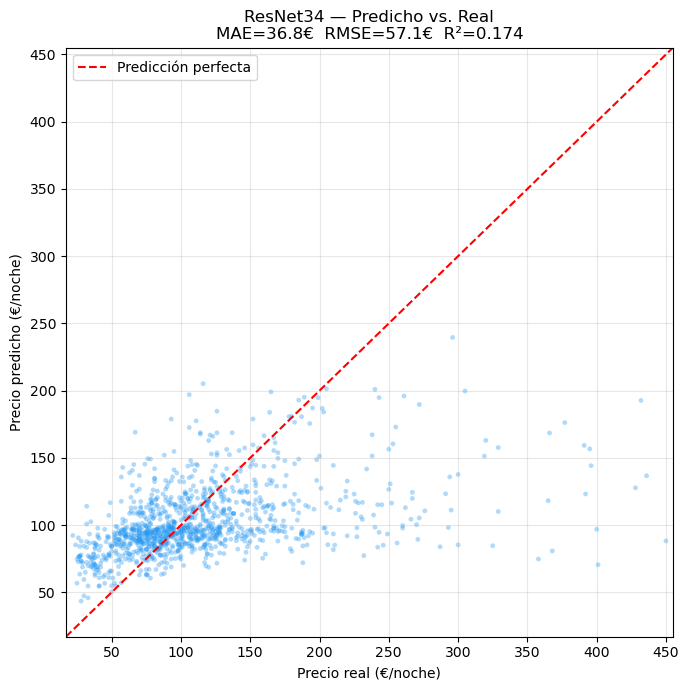


📊 Métricas finales (set validación):
   MAE  = 36.82 €
   RMSE = 57.13 €
   R²   = 0.174
✅ Scatter guardado en models/resnet34_scatter.png


In [14]:
# ============================================================
# 9. SCATTER PREDICHO VS. REAL
# ============================================================

# ── Inferencia final para el scatter ─────────────────────────────────────────
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for imgs, prices in tqdm(loader_val, desc="Inferencia val", leave=False):
        preds_norm  = model(imgs.to(DEVICE))
        # ── Desnormalizar ──
        preds_real  = (preds_norm * PRICE_STD + PRICE_MEAN).cpu().numpy()
        prices_real = (prices     * PRICE_STD + PRICE_MEAN).numpy()

        all_preds.extend(preds_real)
        all_true.extend(prices_real)

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

mae_final  = mean_absolute_error(all_true, all_preds)
rmse_final = np.sqrt(mean_squared_error(all_true, all_preds))
r2_final   = r2_score(all_true, all_preds)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_true, all_preds, alpha=0.35, s=12, edgecolors="none", color="#2196F3")
lims = [min(all_true.min(), all_preds.min()) - 5,
        max(all_true.max(), all_preds.max()) + 5]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Precio real (€/noche)")
ax.set_ylabel("Precio predicho (€/noche)")
ax.set_title(
    f"ResNet34 — Predicho vs. Real\n"
    f"MAE={mae_final:.1f}€  RMSE={rmse_final:.1f}€  R²={r2_final:.3f}",
    fontsize=12
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / "resnet34_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n📊 Métricas finales (set validación):")
print(f"   MAE  = {mae_final:.2f} €")
print(f"   RMSE = {rmse_final:.2f} €")
print(f"   R²   = {r2_final:.3f}")
print("✅ Scatter guardado en models/resnet34_scatter.png")


## 10. Guardado de modelo para fusión

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 10. PERSISTENCIA DEL MODELO Y METADATOS DE NORMALIZACIÓN
# ════════════════════════════════════════════════════════════════════════════
import json

# ── Guardar pesos del mejor modelo ───────────────────────────────────────────
model_path = MODEL_DIR / "resnet34_best.pt"
torch.save(model.state_dict(), model_path)
print(f"✅ Modelo guardado → {model_path}")

# ── Guardar metadatos de normalización ────────────────────────────────────────
# El notebook de fusión necesita estos valores para desnormalizar predicciones
stats = {
    "price_mean": float(PRICE_MEAN),
    "price_std":  float(PRICE_STD),
    "img_size":   IMG_SIZE,
    "architecture": "ResNet34",
    "val_mae":    round(early_stop.best_mae, 4),
    "random_seed": RANDOM_SEED
}
stats_path = MODEL_DIR / "resnet34_price_stats.json"
with open(stats_path, "w") as f:
    json.dump(stats, f, indent=2)

print(f"✅ Metadatos guardados → {stats_path}")
print(f"   PRICE_MEAN = {PRICE_MEAN:.4f} €")
print(f"   PRICE_STD  = {PRICE_STD:.4f} €")

## 11. Extración embeddings

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 11. EXTRACCIÓN DE EMBEDDINGS — Backbone ResNet34 sin cabeza fc
# Genera un vector de 512 dimensiones por imagen para el modelo de fusión
# ════════════════════════════════════════════════════════════════════════════

# ── Crear backbone: ResNet34 sin la cabeza fc ─────────────────────────────────
class ResNet34Backbone(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        # Copiamos todas las capas excepto la cabeza fc
        self.conv1   = full_model.conv1
        self.bn1     = full_model.bn1
        self.relu    = full_model.relu
        self.maxpool = full_model.maxpool
        self.layer1  = full_model.layer1
        self.layer2  = full_model.layer2
        self.layer3  = full_model.layer3
        self.layer4  = full_model.layer4
        self.avgpool = full_model.avgpool

    def forward(self, x):
        x = self.conv1(x);   x = self.bn1(x);  x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x);  x = self.layer2(x)
        x = self.layer3(x);  x = self.layer4(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)   # → (batch, 512)

backbone = ResNet34Backbone(model).to(DEVICE)
backbone.eval()

# ── Dataset sin shuffle para TODO df_sync ────────────────────────────────────
dataset_full = AirbnbImageDataset(df_sync, IMG_DIR, transform=transform_val)
loader_full  = DataLoader(dataset_full, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0, pin_memory=True)

# ── Inferencia ────────────────────────────────────────────────────────────────
all_embeddings = []
all_ids        = []

with torch.no_grad():
    for batch_idx, (imgs, _) in enumerate(tqdm(loader_full, desc="Extrayendo embeddings")):
        emb = backbone(imgs.to(DEVICE))          # (batch, 512)
        all_embeddings.append(emb.cpu().numpy())
        # Recuperar los IDs correspondientes a este batch
        start = batch_idx * BATCH_SIZE
        end   = start + imgs.size(0)
        all_ids.extend(df_sync["id"].iloc[start:end].tolist())

embeddings_matrix = np.vstack(all_embeddings)    # (5667, 512)

print(f"\n📐 Shape embeddings: {embeddings_matrix.shape}")
print(f"   {embeddings_matrix.shape[0]} apartamentos × {embeddings_matrix.shape[1]} dimensiones")

# ── Guardar como CSV con ID ────────────────────────────────────────────────────
cols = ["id"] + [f"emb_{i}" for i in range(512)]
df_emb = pd.DataFrame(
    np.column_stack([all_ids, embeddings_matrix]),
    columns=cols
)
df_emb["id"] = df_emb["id"].astype(int)

emb_path = pathlib.Path("../data/resnet34_embeddings.csv")
df_emb.to_csv(emb_path, index=False)

# ── También guardar como .npy (más eficiente para PyTorch) ───────────────────
np.save(pathlib.Path("../data/resnet34_embeddings.npy"), embeddings_matrix)
np.save(pathlib.Path("../data/resnet34_ids.npy"),        np.array(all_ids))

print(f"\n✅ Embeddings guardados:")
print(f"   CSV  → ../data/resnet34_embeddings.csv  ({df_emb.shape[0]} filas × {df_emb.shape[1]} cols)")
print(f"   NPY  → ../data/resnet34_embeddings.npy  (matrix {embeddings_matrix.shape})")
print(f"   NPY  → ../data/resnet34_ids.npy         ({len(all_ids)} IDs)")